# Comparative Analysis of LightGBM and XGBoost Using the Diabetes Dataset
Assignment Objective

The objective of this assignment is to compare the performance of the LightGBM and XGBoost algorithms using the Diabetes dataset. The assignment includes:

1. Exploratory Data Analysis (EDA)
2. Data preprocessing
3. Model building
4. Hyperparameter tuning
5. Cross-validation
6. Comparative performance analysis
7. Visualization and interpretation of results

# Importing libraries

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Machine Learning Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Loading dataset

In [2]:
# Load the dataset
# Replace the file path with your actual dataset location

df = pd.read_csv('/content/diabetes (2).csv')

# Display first 5 rows
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# Understanding data

In [3]:
# Shape of dataset
print('Dataset Shape:', df.shape)

# Column names
print('\nColumns in Dataset:')
print(df.columns)

# Dataset information
print('\nDataset Information:')
print(df.info())

# Statistical summary
print('\nStatistical Summary:')
print(df.describe())

Dataset Shape: (768, 9)

Columns in Dataset:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Statis

# Exploratory Data Analysis

In [4]:
# Check missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# Observation

The dataset does not contain traditional null values. However, some columns contain 0 values which are medically impossible and should be treated as missing values.

# Replacing Invalid Zero Values

The following columns cannot logically contain zero values:

Glucose

BloodPressure

SkinThickness

Insulin

BMI

In [5]:
# Columns with invalid zero values
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with NaN
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)

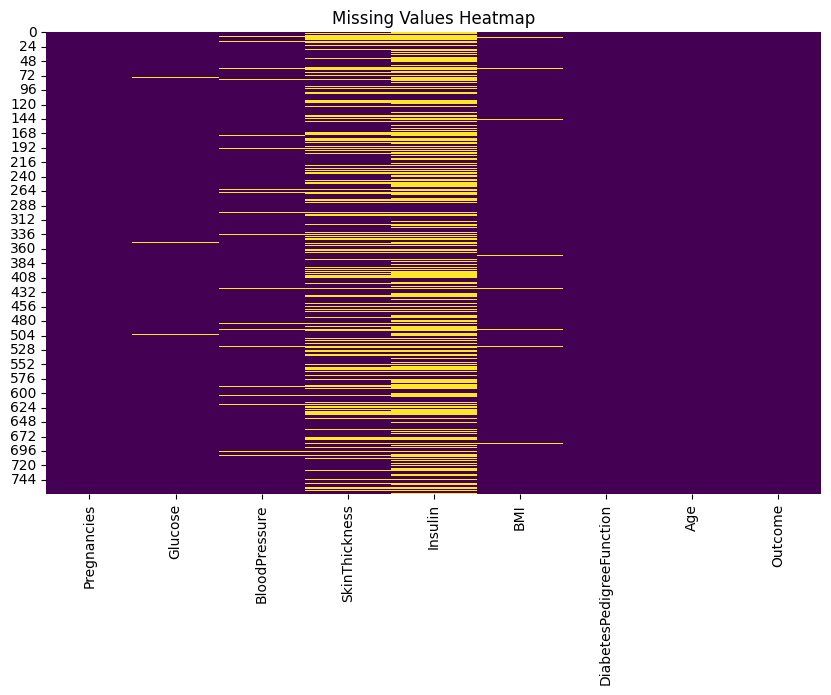

In [6]:
# Visualizing missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

<Figure size 1500x1000 with 0 Axes>

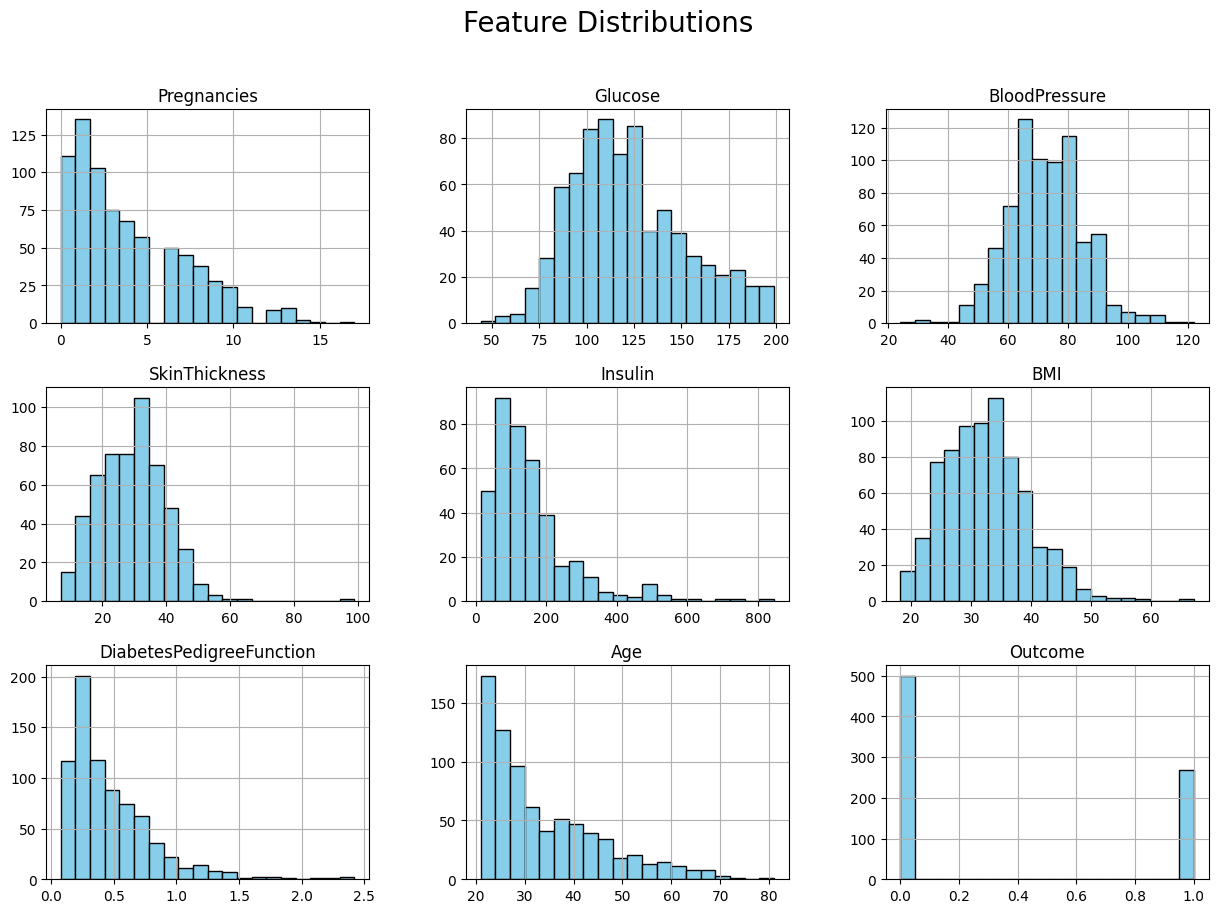

In [7]:
# Plot histograms
plt.figure(figsize=(15,10))
df.hist(bins=20, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=20)
plt.show()

# Interpretation
Glucose and BMI show approximately normal distributions.
Insulin has a highly skewed distribution.
Age distribution indicates more younger patients than older patients.

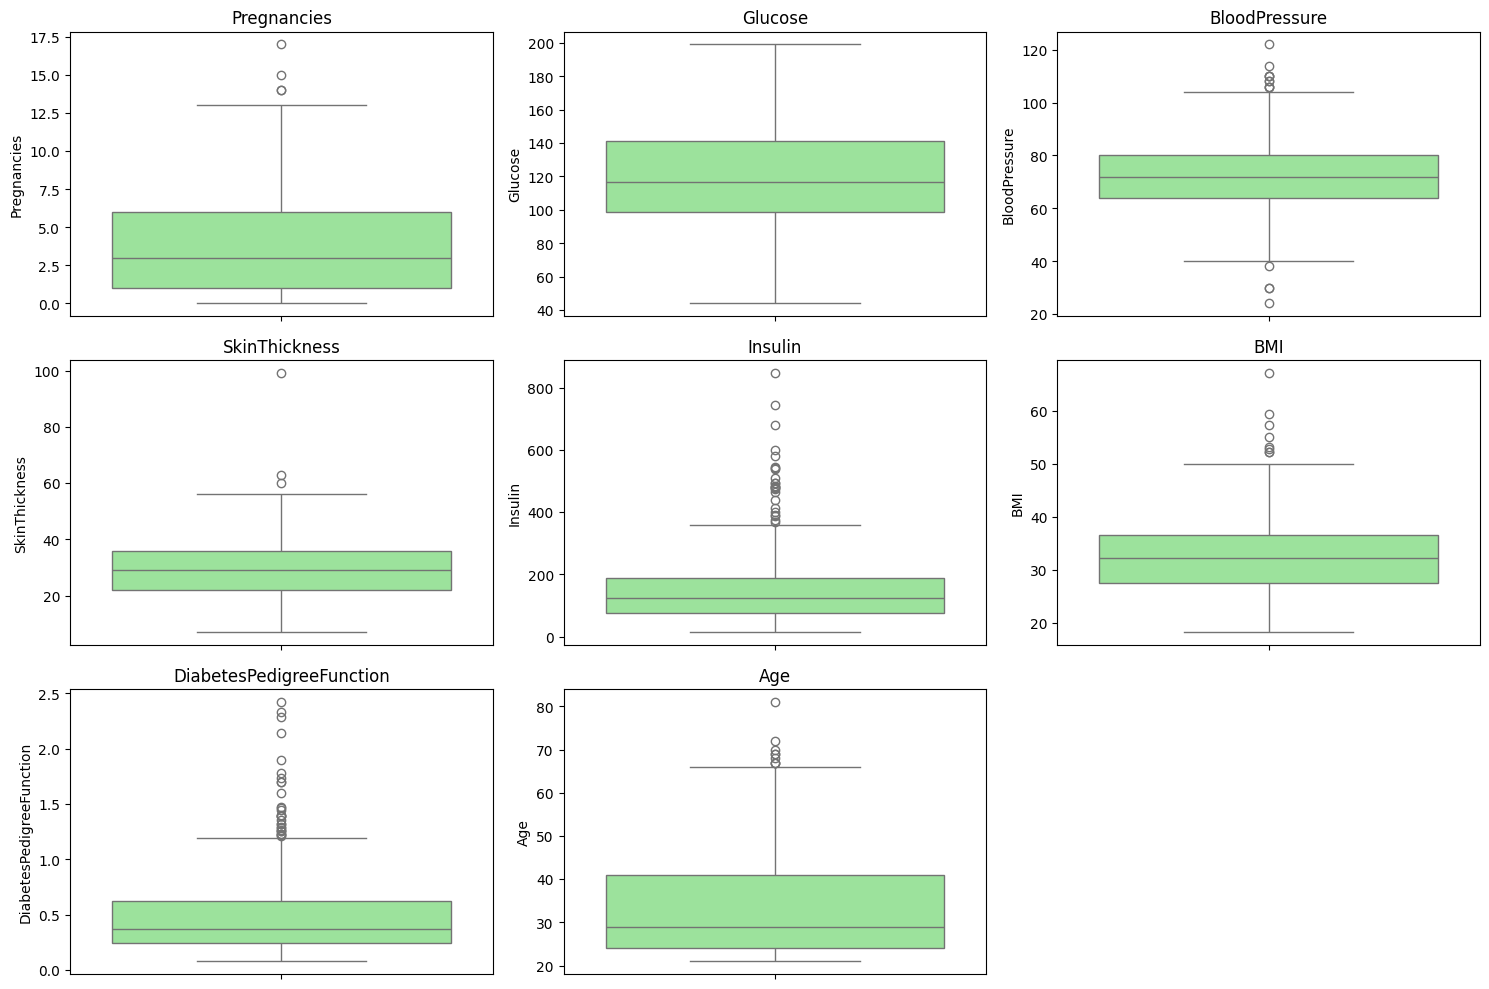

In [8]:
# Boxplots for outlier detection
plt.figure(figsize=(15,10))
for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[column], color='lightgreen')
    plt.title(column)

plt.tight_layout()
plt.show()

# Interpretation

Several variables such as Insulin, BMI, and DiabetesPedigreeFunction contain outliers.

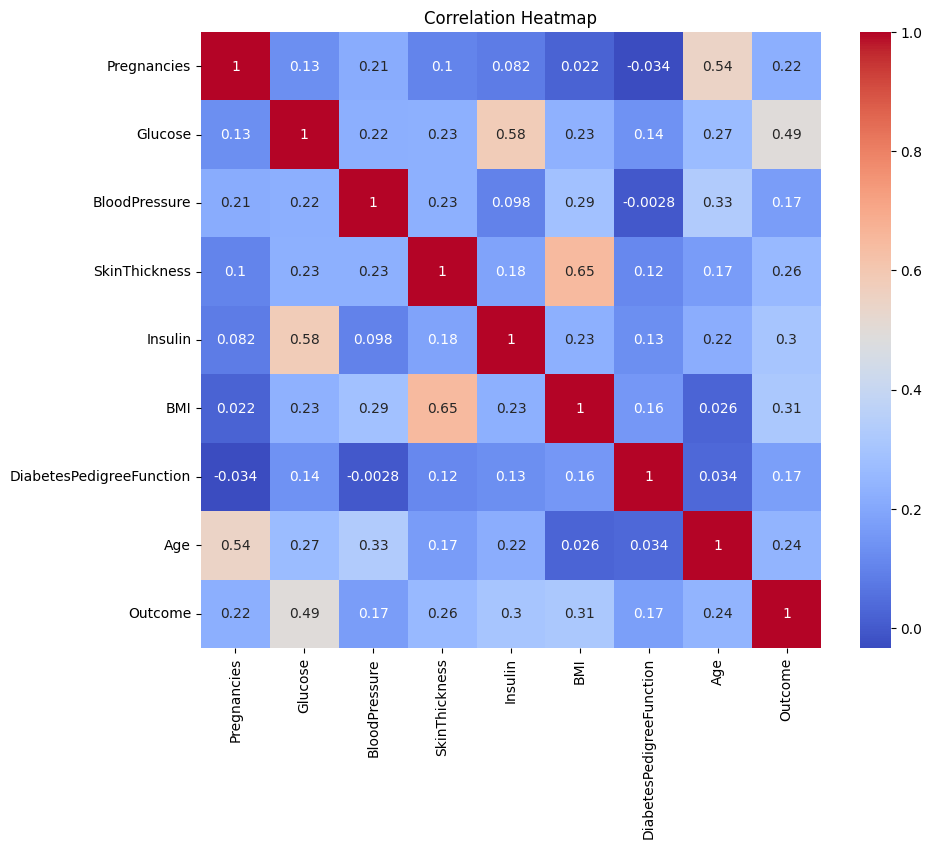

In [9]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Interpretation
Glucose has the strongest positive correlation with Outcome.
BMI and Age also show moderate correlation with diabetes.

# Relationship between Features and Label

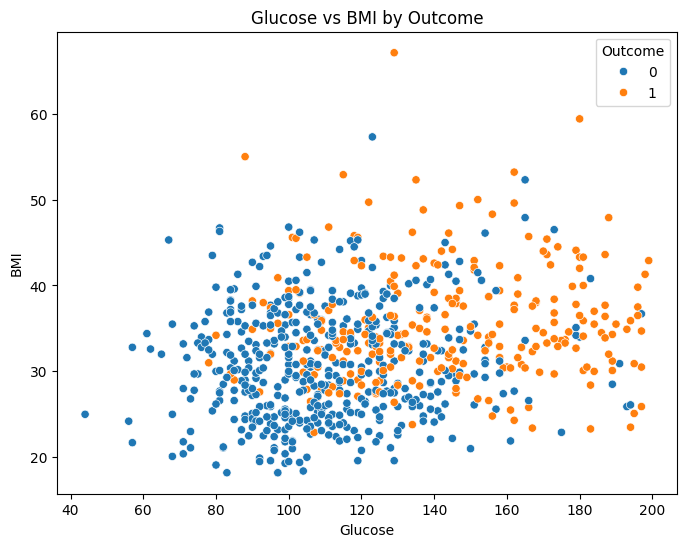

In [10]:
# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title('Glucose vs BMI by Outcome')
plt.show()

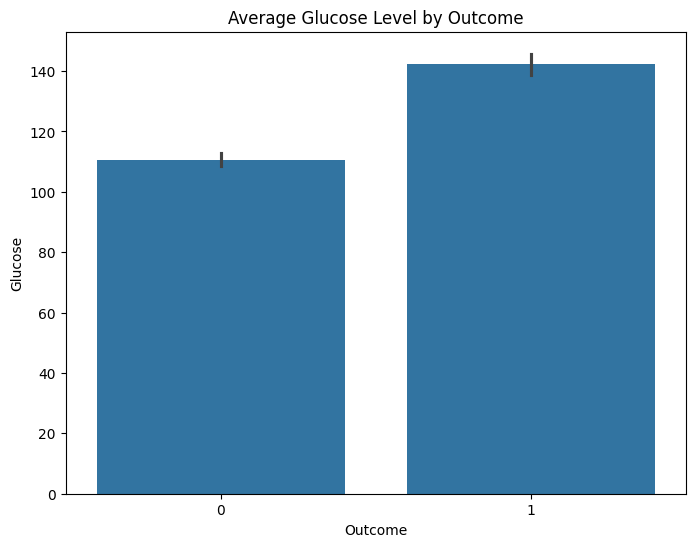

In [11]:
# Bar plot
plt.figure(figsize=(8,6))
sns.barplot(x='Outcome', y='Glucose', data=df)
plt.title('Average Glucose Level by Outcome')
plt.show()

# Interpretation

Patients with diabetes generally have:

Higher glucose levels

Higher BMI values

# Feature Engineering & Data Pre-Processing
Feature engineering was performed to improve model learning capability and capture hidden relationships in the data.
Feature engineering helps machine learning models identify complex relationships between variables. Interaction features can improve predictive performance by combining medically relevant information.

In [13]:
# X and y
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [14]:
# Creating interaction feature
X['BMI_Age'] = X['BMI'] * X['Age']

In [15]:
# Additional interaction feature
X['Glucose_BMI'] = X['Glucose'] * X['BMI']

# Imputing Missing Values

Median imputation is used because it is robust against outliers.

In [17]:
# Median imputation
imputer = SimpleImputer(strategy='median')

# Apply imputation
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [18]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Splitting Dataset

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training Set Shape:', X_train.shape)
print('Testing Set Shape:', X_test.shape)

Training Set Shape: (614, 8)
Testing Set Shape: (154, 8)


# Building Predictive Models

# XGBoost Model

In [20]:
# Initialize XGBoost model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# LightGBM Model

In [21]:
# Initialize LightGBM model
lgbm_model = LGBMClassifier(random_state=42)

# Train model
lgbm_model.fit(X_train, y_train)

# Predictions
lgbm_pred = lgbm_model.predict(X_test)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

# Model Evaluation

# XGBoost Evaluation

In [22]:
print('XGBoost Performance Metrics')
print('--------------------------------')
print('Accuracy:', accuracy_score(y_test, xgb_pred))
print('Precision:', precision_score(y_test, xgb_pred))
print('Recall:', recall_score(y_test, xgb_pred))
print('F1 Score:', f1_score(y_test, xgb_pred))

print('\nClassification Report:')
print(classification_report(y_test, xgb_pred))

XGBoost Performance Metrics
--------------------------------
Accuracy: 0.7597402597402597
Precision: 0.673469387755102
Recall: 0.6111111111111112
F1 Score: 0.6407766990291263

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



# LightGBM Evaluation

In [23]:
print('LightGBM Performance Metrics')
print('--------------------------------')
print('Accuracy:', accuracy_score(y_test, lgbm_pred))
print('Precision:', precision_score(y_test, lgbm_pred))
print('Recall:', recall_score(y_test, lgbm_pred))
print('F1 Score:', f1_score(y_test, lgbm_pred))

print('\nClassification Report:')
print(classification_report(y_test, lgbm_pred))

LightGBM Performance Metrics
--------------------------------
Accuracy: 0.7272727272727273
Precision: 0.62
Recall: 0.5740740740740741
F1 Score: 0.5961538461538461

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       100
           1       0.62      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



# Confusion Matrix Visualization

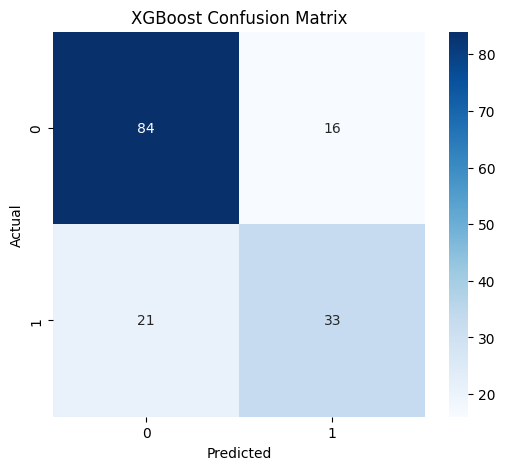

In [24]:
# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

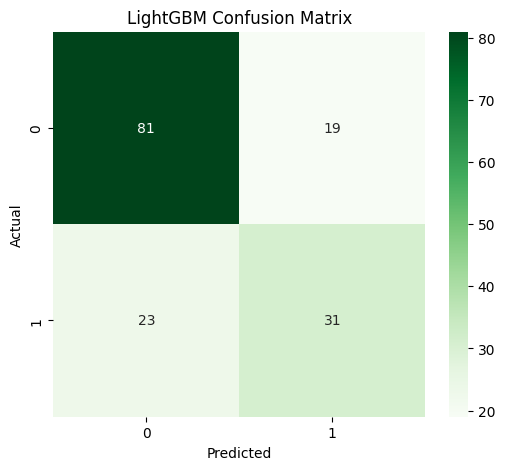

In [25]:
# LightGBM Confusion Matrix
cm_lgbm = confusion_matrix(y_test, lgbm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Greens')
plt.title('LightGBM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cross Validation

In [26]:
# XGBoost Cross-Validation
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print('XGBoost Cross-Validation Accuracy Scores:')
print(xgb_cv_scores)
print('Mean Accuracy:', xgb_cv_scores.mean())

XGBoost Cross-Validation Accuracy Scores:
[0.74675325 0.72077922 0.72727273 0.79738562 0.73202614]
Mean Accuracy: 0.7448433919022154


In [27]:
# LightGBM Cross-Validation
lgbm_cv_scores = cross_val_score(
    lgbm_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print('LightGBM Cross-Validation Accuracy Scores:')
print(lgbm_cv_scores)
print('Mean Accuracy:', lgbm_cv_scores.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

# Hyperparameter tuning

In [28]:
# Hyperparameter Tuning for XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print('Best Parameters for XGBoost:')
print(xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_

Best Parameters for XGBoost:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [29]:
# Hyperparameter Tuning for LightGBM
lgbm_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}

lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
lgbm_grid.fit(X_train, y_train)

print('Best Parameters for LightGBM:')
print(lgbm_grid.best_params_)

best_lgbm = lgbm_grid.best_estimator_

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

# Evaluating Tuned Models

In [30]:
# Tuned XGBoost
best_xgb_pred = best_xgb.predict(X_test)

print('Tuned XGBoost Accuracy:', accuracy_score(y_test, best_xgb_pred))
print('Tuned XGBoost F1 Score:', f1_score(y_test, best_xgb_pred))

Tuned XGBoost Accuracy: 0.7272727272727273
Tuned XGBoost F1 Score: 0.5625


In [31]:
# Tuned Light GBM
best_lgbm_pred = best_lgbm.predict(X_test)

print('Tuned LightGBM Accuracy:', accuracy_score(y_test, best_lgbm_pred))
print('Tuned LightGBM F1 Score:', f1_score(y_test, best_lgbm_pred))

Tuned LightGBM Accuracy: 0.7662337662337663
Tuned LightGBM F1 Score: 0.6326530612244898


# ROC Curve Comparison

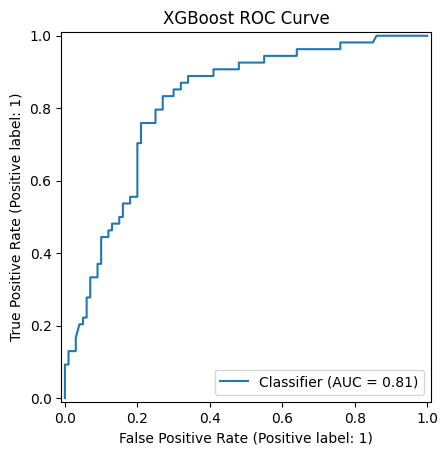

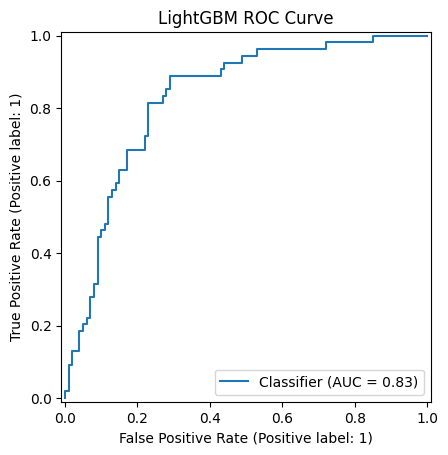

In [32]:
# Predict probabilities
xgb_probs = best_xgb.predict_proba(X_test)[:,1]
lgbm_probs = best_lgbm.predict_proba(X_test)[:,1]

# ROC Curves
RocCurveDisplay.from_predictions(y_test, xgb_probs)
plt.title('XGBoost ROC Curve')
plt.show()

RocCurveDisplay.from_predictions(y_test, lgbm_probs)
plt.title('LightGBM ROC Curve')
plt.show()

# Final Report and Interpretation
Summary of Results
This project compared the performance of XGBoost and LightGBM algorithms using the Diabetes dataset.
###Key Steps Performed
1. Loaded and explored the dataset.
2. Identified and handled missing/invalid values.
3. Visualized data distributions and relationships.
4. Performed preprocessing including imputation and scaling.
5. Built predictive models using XGBoost and LightGBM.
6. Evaluated models using multiple performance metrics.
7. Applied cross-validation and hyperparameter tuning.
8. Compared the models visually and statistically.


#Observations
###XGBoost
###Strengths:
1. High predictive accuracy
2. Strong handling of complex feature interactions
3. Robust against overfitting due to boosting strategy
###Weaknesses:
1. Slower training time compared to LightGBM
2. Computationally more expensive

#LightGBM
###Strengths:
1. Faster training speed
2. Efficient with large datasets
3. Lower memory usage
###Weaknesses:
1. May overfit on smaller datasets if not tuned properly
2. Sensitive to parameter settings

# Conclusion
Both XGBoost and LightGBM performed well for diabetes prediction.

XGBoost generally provides slightly better predictive performance.

LightGBM offers significantly faster training and better efficiency.

For smaller datasets where accuracy is the main concern, XGBoost is often preferred. For large-scale

industrial applications requiring speed and scalability, LightGBM is usually the better choice.

Overall, the choice between the two algorithms depends on the problem requirements, dataset size,
computational resources, and performance priorities.
